# Import Library



In [25]:
import kagglehub
import os
import shutil # Memungkinkan operasi tingkat tinggi pada sejumlah file dan koleksi file
import matplotlib.pyplot as plt
import tensorflow as tf # Untuk komputasi numerik berkinerja tinggi
import keras # Kerangka kerja pembelajaran mendalam multi-backend
import pandas as pd
import numpy as np
import seaborn as sns # Visualisasi data statistik
import cv2 # Pustaka perangkat lunak visi komputer
import warnings
import time
import random

# Menyesuaikan generator data dengan beberapa data sampel
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0, ResNet152, VGG16
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
from google.colab import files

# Menghilangkan peringatan log dari Keras/TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore', category=UserWarning)

# Download Dataset dari Kaggle

In [4]:
# Mengunduh dan menetapkan jalur direktori dataset CT-Scan ginjal dari Kaggle secara otomatis.
path = kagglehub.dataset_download("nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone")
print("Jalur ke file dataset: ", path)
dataset_path = path
parent_dir = os.path.join(dataset_path, "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# Tentukan jalur untuk setiap jenis kasus
normal_cases_path = os.path.join(parent_dir, "Normal")
cyst_cases_path = os.path.join(parent_dir, "Cyst")
tumor_cases_path = os.path.join(parent_dir, "Tumor")
stone_cases_path = os.path.join(parent_dir, "Stone")

# Cetak jalur untuk memverifikasi
print(f"Normal cases path: {normal_cases_path}")
print(f"Cyst cases path: {cyst_cases_path}")
print(f"Tumor cases path: {tumor_cases_path}")
print(f"Stone cases path: {stone_cases_path}")

Using Colab cache for faster access to the 'ct-kidney-dataset-normal-cyst-tumor-and-stone' dataset.
Jalur ke file dataset:  /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone
Normal cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal
Cyst cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst
Tumor cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor
Stone cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone


# Exploratory Data Analysis (EDA)

In [5]:
# Menghitung jumlah file di setiap folder
num_normal = len(os.listdir(normal_cases_path))
num_cyst = len(os.listdir(cyst_cases_path))
num_tumor = len(os.listdir(tumor_cases_path))
num_stone = len(os.listdir(stone_cases_path))

# Menampilkan hasil
print(f"Jumlah data Awal :")
print(f"Jumlah data Normal: {num_normal}")
print(f"Jumlah data Cyst: {num_cyst}")
print(f"Jumlah data Tumor: {num_tumor}")
print(f"Jumlah data Stone: {num_stone}")

# Menghitung total keseluruhan
total_data = num_normal + num_cyst + num_tumor + num_stone
print(f"\nTotal seluruh data: {total_data}")

Jumlah data Awal :
Jumlah data Normal: 5077
Jumlah data Cyst: 3709
Jumlah data Tumor: 2283
Jumlah data Stone: 1377

Total seluruh data: 12446


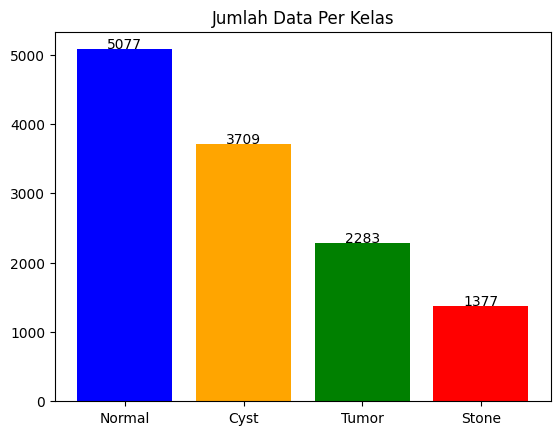

In [6]:
# Data Folders
data_folders = {
  "Normal": num_normal,
  "Cyst": num_cyst,
  "Tumor": num_tumor,
  "Stone": num_stone,
}

# Hitung jumlah file sekaligus ambil nama kategorinya
labels = list(data_folders.keys())
counts = list(data_folders.values()) # Corrected: Directly use the stored counts

# Tampilkan Grafik
plt.bar(labels, counts, color=['blue', 'orange', 'green', 'red'])
plt.title("Jumlah Data Per Kelas")

# Tambahkan angka di atas setiap batang agar jelas
for i, v in enumerate(counts):
  plt.text(i, v+10, str(v), ha='center')

plt.show()

"Karena datasets asli tidak seimbang, maka akan dilakukan pengambilan subset sebesar 1.000 citra per kelas (total 4.000 data) dilakukan untuk menerapkan strategi Undersampling. Hal ini bertujuan untuk menyeimbangkan distribusi data (Balanced Dataset) guna menghindari bias prediksi pada kelas mayoritas, serta mengoptimalkan efisiensi waktu komputasi tanpa mengurangi kemampuan model dalam mengekstraksi fitur-fitur penting."

# Data Balancing (Undersampling)

In [7]:
# Buat folder baru untuk menyimpan subset dataset
subset_dir = os.path.join("/content/drive/MyDrive/ColabNotebooks/Datasets", "Dataset_Subset_1000")
# Change dataset_path to a writable locationos.makedirs(subset_dir, exist_ok=True)
os.makedirs(subset_dir, exist_ok=True)

# Dictionary dari path sumber
categories = {
  "Normal": normal_cases_path,
  "Cyst": cyst_cases_path,
  "Tumor": tumor_cases_path,
  "Stone": stone_cases_path
}

# Proses menyalin 1000 file pertama
for label, source_path in categories.items():
  # Buat sub-folder untuk setiap class di dalam folder subset
  target_path = os.path.join(subset_dir, label)
  os.makedirs(target_path, exist_ok=True)

  # Ambil 1000 file pertama (diurutkan)
  files_to_copy = sorted(os.listdir(source_path))[:1000]

  # Copy file dari sumber ke target
  for file_name in files_to_copy:
    src_file = os.path.join(source_path, file_name)
    dst_file = os.path.join(target_path, file_name)
    shutil.copy(src_file, dst_file)

  print(f"Berhasil menyalin {len(files_to_copy)} file untuk class {label}")

print("\nDataset subset berhasil dibuat di:", subset_dir)

Berhasil menyalin 1000 file untuk class Normal
Berhasil menyalin 1000 file untuk class Cyst
Berhasil menyalin 1000 file untuk class Tumor
Berhasil menyalin 1000 file untuk class Stone

Dataset subset berhasil dibuat di: /content/drive/MyDrive/ColabNotebooks/Datasets/Dataset_Subset_1000


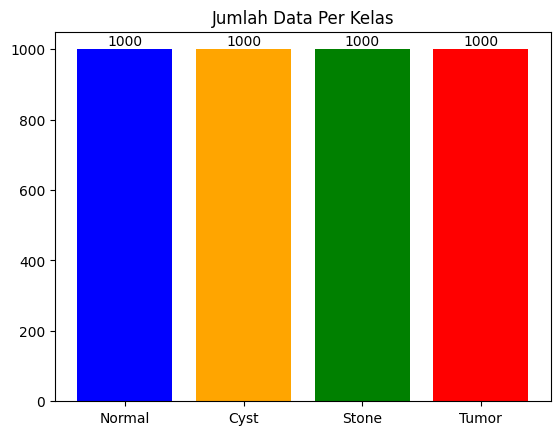

In [8]:
# Gabungkan label dan path dalam satu Dictionary
data_folders = {
  "Normal": "/content/drive/MyDrive/ColabNotebooks/Datasets/Dataset_Subset_1000/Normal",
  "Cyst": "/content/drive/MyDrive/ColabNotebooks/Datasets/Dataset_Subset_1000/Cyst",
  "Stone": "/content/drive/MyDrive/ColabNotebooks/Datasets/Dataset_Subset_1000/Stone",
  "Tumor": "/content/drive/MyDrive/ColabNotebooks/Datasets/Dataset_Subset_1000/Tumor"
}

# Hitung jumlah file sekaligus ambil nama kategorinya
labels = list(data_folders.keys())
counts = [len(os.listdir(p)) for p in data_folders.values()]

# Tampilkan Grafik
plt.bar(labels, counts, color=['blue', 'orange', 'green', 'red'])
plt.title("Jumlah Data Per Kelas")

# Tambahkan angka di atas setiap batang agar jelas
for i, v in enumerate(counts):
  plt.text(i, v+10, str(v), ha='center')

plt.show()

# Segmentasi Citra

Otsu thresholding digunakan untuk memisahkan objek utama (ginjal atau area kelainan seperti cyst, tumor, dan stone) dari latar belakang pada citra CT secara otomatis berdasarkan distribusi intensitas piksel.

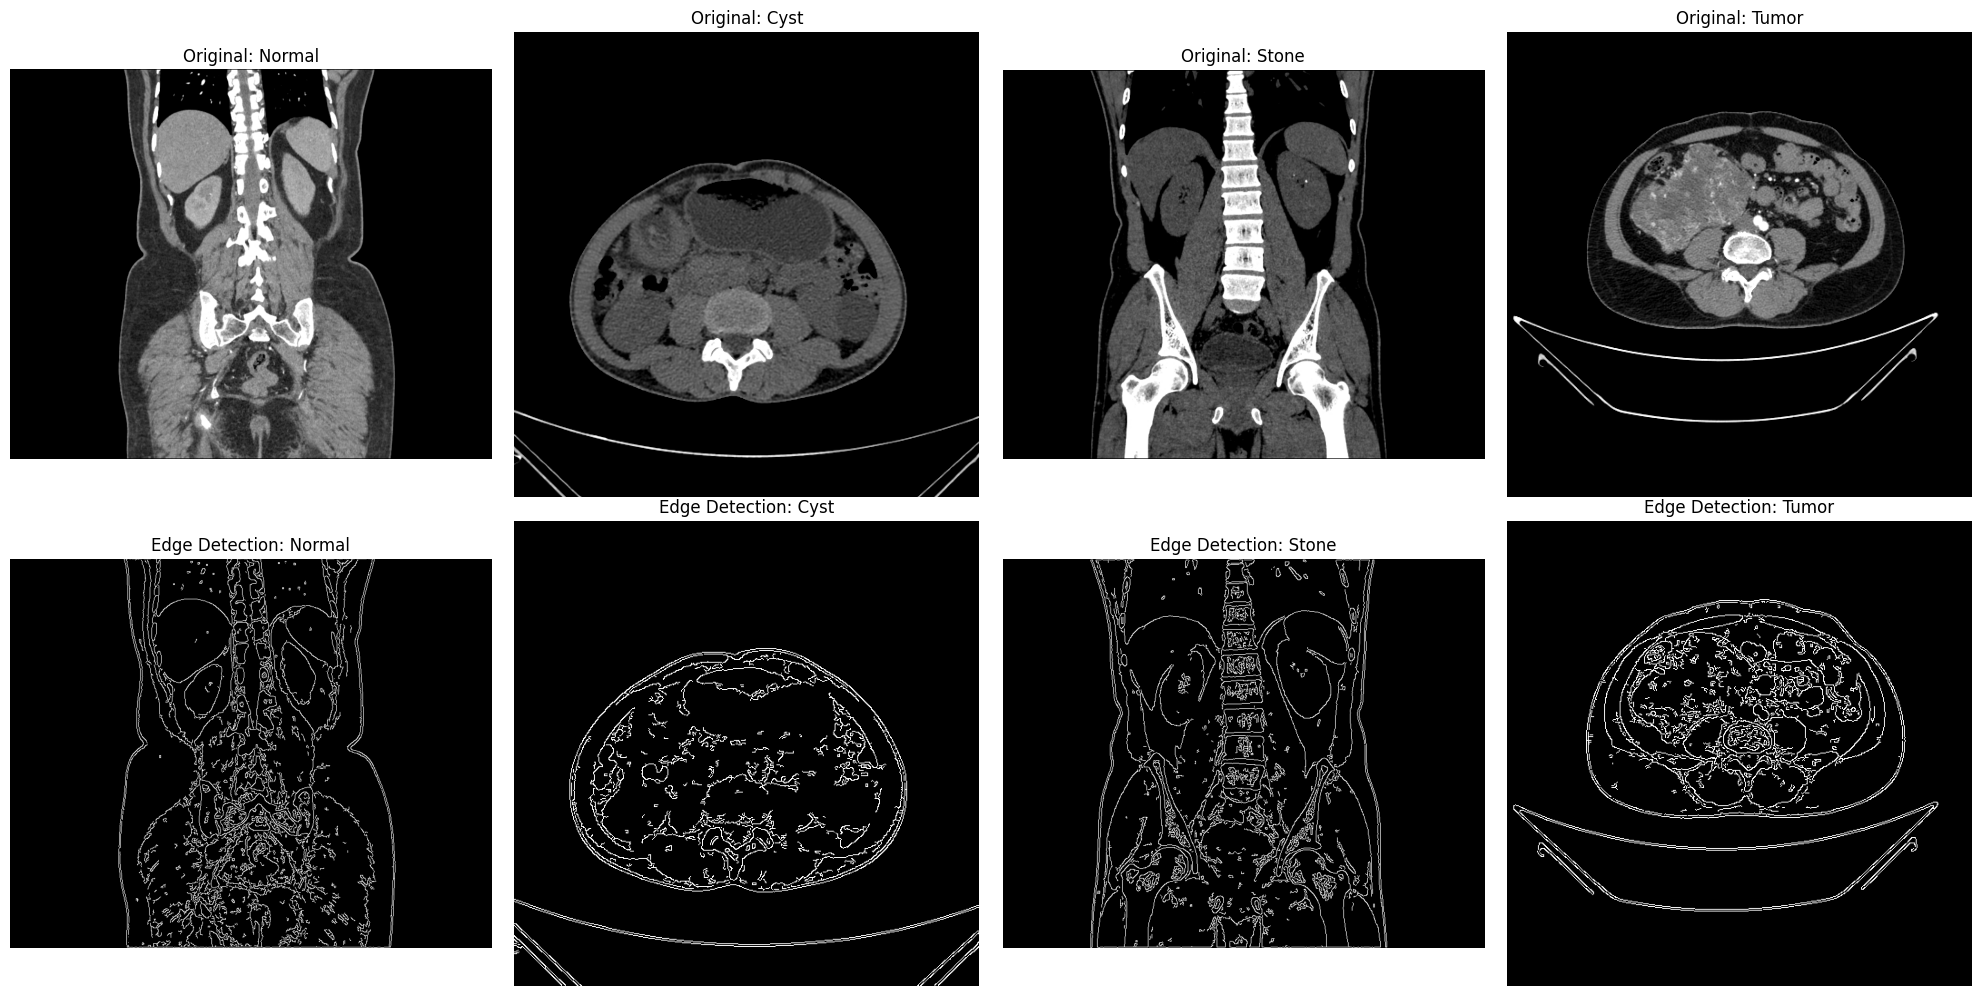

In [9]:
# Visualisasi Segmentasi Tepi (Edge Detection)
plt.figure(figsize=(20, 10))

for i, (class_name, folder_path) in enumerate(data_folders.items()):
  # Ambil file pertama
  file_names = os.listdir(folder_path)
  if not file_names: continue

  img_path = os.path.join(folder_path, file_names[0])
  img = cv2.imread(img_path)
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # --- Teknik Segmentasi Medis: Canny Edge Detection ---
  # Ini akan mendeteksi garis tepi Tumor, Stone, atau Cyst
  edges = cv2.Canny(img_gray, 100, 200)

  # Tampilkan Gambar Asli
  plt.subplot(2, 4, i + 1)
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.title(f"Original: {class_name}")
  plt.axis('off')

  # Tampilkan Hasil Segmentasi Tepi
  plt.subplot(2, 4, i + 5)
  plt.imshow(edges, cmap='gray')
  plt.title(f"Edge Detection: {class_name}")
  plt.axis('off')

plt.tight_layout()
plt.show()

Otsu Segmentation digunakan untuk memisahkan objek utama (ginjal atau area kelainan seperti cyst, tumor, dan stone) dari latar belakang pada citra CT secara otomatis berdasarkan distribusi intensitas piksel.

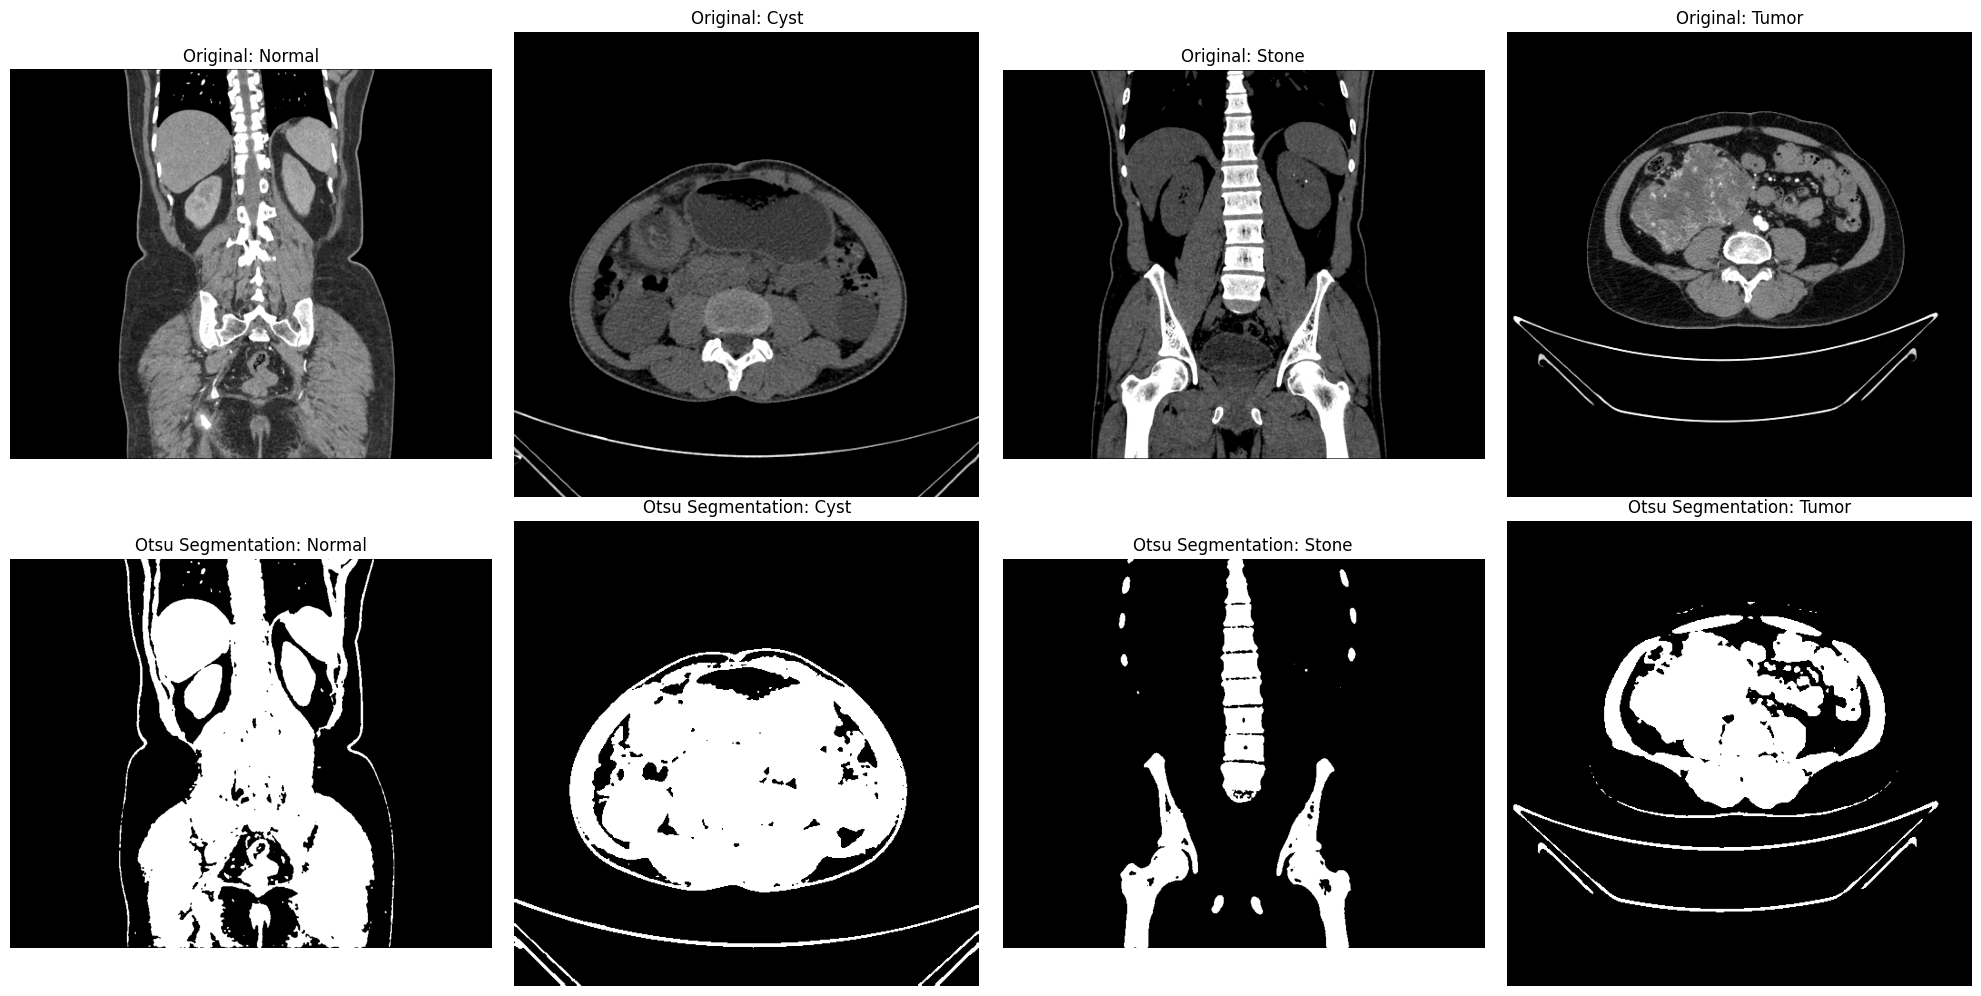

In [10]:
# Visualisasi Otsu Segmentation (Segmented Mask)
plt.figure(figsize=(20, 10))

for i, (class_name, folder_path) in enumerate(data_folders.items()):
  # Ambil file pertama dari folder masing-masing kelas
  file_names = os.listdir(folder_path)
  if not file_names: continue

  img_path = os.path.join(folder_path, file_names[0])
  img = cv2.imread(img_path)
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # --- Teknik Segmentasi Medis: Otsu Thresholding ---
  # 1. Gunakan Gaussian Blur untuk mengurangi (bintik-bintik halus)
  blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

  # 2. Otsu secara otomatis mencari nilai ambang batas (threshold) optimal.
  ret, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  # Tampilkan Gambar Asli
  plt.subplot(2, 4, i + 1)
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.title(f"Original: {class_name}")
  plt.axis('off')

  # Tampilkan Hasil Otsu Segmentation
  plt.subplot(2, 4, i + 5)
  plt.imshow(thresh, cmap='gray')
  plt.title(f"Otsu Segmentation: {class_name}")
  plt.axis('off')

plt.tight_layout()
plt.show()

Untuk dataset CT-Kidney yang berisi citra CT-scan ginjal (Normal, Cyst, Tumor, Stone), teknik segmentasi citra bertujuan untuk memisahkan area ginjal dari latar belakang atau mengisolasi lesi (batu, kista, atau tumor) dari jaringan sehat.

In [11]:
# Segmentasi
def combined_segmentation_preprocess(img):
  # 1. Pastikan citra dalam format uint8 (0-255) agar OpenCV berfungsi
  img_uint8 = img.astype(np.uint8)

  # 2. Preprocessing dasar: Grayscale dan Blur
  gray = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
  blur = cv2.GaussianBlur(gray, (5, 5), 0)

  # 3. Teknik 1: Otsu Thresholding (Mendapatkan "Isi" objek)
  _, otsu_mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  # 4. Teknik 2: Canny Edge Detection (Mendapatkan "Garis Tepi")
  edges = cv2.Canny(blur, 100, 200)

  # 5. Gabungkan Keduanya dengan Bitwise OR
  hybrid_mask = cv2.bitwise_or(otsu_mask, edges)

  # 6. Konversi kembali ke 3-channel (RGB)
  hybrid_rgb = cv2.cvtColor(hybrid_mask, cv2.COLOR_GRAY2RGB)

  # 7. Final Step: Masukkan ke Preprocess Input bawaan EfficientNet
  final_img = tf.keras.applications.efficientnet.preprocess_input(hybrid_rgb)

  return final_img

# Data Augmentation & Split Dataset

Found 2800 images belonging to 4 classes.
Found 1200 images belonging to 4 classes.
Batch Size:  32


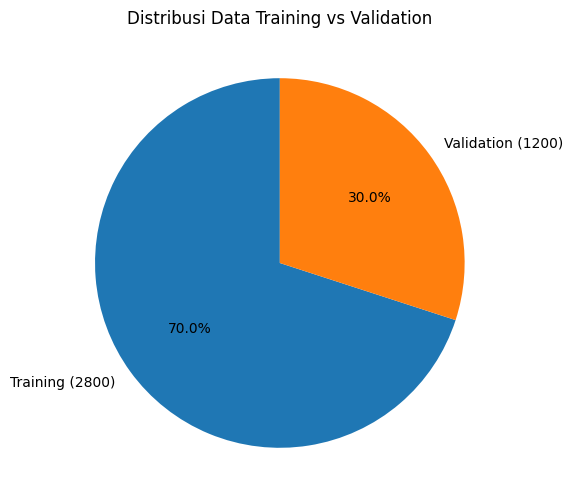

In [12]:
# Mengubah semua gambar dengan ukuran 224x224 piksel
IMG_HEIGHT = 224
IMG_WIDTH = 224
# Model belajar dari 32 gambar per satu langkah pelatihan
BATCH_SIZE = 32 # Hyperparameter (BATCH_SIZE = 32, 64, 128)

# Membuat data "tiruan" yang bervariasi dari data asli
train_datagen = ImageDataGenerator(
  # Mengubah nilai setiap piksel (0-255) menjadi rentang 0 hingga 1# Mengubah nilai setiap piksel (0-255) menjadi rentang 0 hingga 1
  preprocessing_function=combined_segmentation_preprocess,
  # Memutar dan menggeser gambar secara horizontal/vertikal.
  rotation_range=40,
  width_shift_range=0.2,
  height_shift_range=0.2,
  # Memberikan efek miring (distorsi) dan memperbesar/memperkecil gambar secara acak
  shear_range=0.2,
  zoom_range=0.2,
  # Membalik gambar secara horizontal (seperti cermin)
  horizontal_flip=True,
  # Mengubah tingkat kecerahan gambar (dari redup hingga terang)
  brightness_range=[0.5, 1.5],
  # Jika saat diputar ada bagian kosong di pojok gambar.
  fill_mode='nearest',
  # 20% for validation
  validation_split=0.3
)

# Data validasi tidak diberikan augmentasi (seperti rotasi atau flip)
validation_datagen = ImageDataGenerator(
  # Data validasi hanya di rescale saja
  # rescale=1./255,
  preprocessing_function=combined_segmentation_preprocess,
  validation_split=0.3
  # 30% data untuk validation
  # 70% data untuk training
)

# Bagian ini menghubungkan kode dengan folder di drive
train_generator = train_datagen.flow_from_directory(
  subset_dir, # Folder sumber diisi dengan 1000 gambar per kelas
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical', # Digunakan karena label memiliki 4 kelas
  subset='training',
  # Training: Mengambil 80% data untuk belajar
  # Validation: Mengambil 20% sisanya untuk ujian tengah semester model
  seed=42 # Memastikan pembagian data selalu sama setiap kali kode dijalankan
)

# Muat gambar dari parent_dir untuk validasi
validation_generator = validation_datagen.flow_from_directory(
  subset_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  subset='validation',
  seed=42
)

# Ambil jumlah data dari generator
print("Batch Size: ", BATCH_SIZE)
counts = [train_generator.samples, validation_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})']

# Plot diagram lingkaran (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Ambil semua path file dan label dari subset_dir (yang berisi 1000 per kelas)
filenames = []
labels = []

# Membaca folder kategori (Class)
for category in os.listdir(subset_dir):
  # Membuat alamat lengkap folder
  category_path = os.path.join(subset_dir, category)
  # Memastikan itu adalah folder
  if os.path.isdir(category_path):
    # Mendata setiap file gambar
    for file in os.listdir(category_path):
      filenames.append(os.path.join(category_path, file))
      labels.append(category)

# Membuat tabel (DataFrame)
df = pd.DataFrame({'filename': filenames, 'label': labels})

# Pembagian: 70% Train, 30% Sisanya (untuk Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
# Pembagian Sisa (30%) menjadi dua: 15% Val dan 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Training Images: {len(train_df)} Images")
print(f"Validation Images: {len(val_df)} Images")
print(f"Testing Images: {len(test_df)} Images")

Training Images: 2800 Images
Validation Images: 600 Images
Testing Images: 600 Images


# Data Generator

Found 2800 validated image filenames belonging to 4 classes.
Found 600 validated image filenames belonging to 4 classes.
Found 600 validated image filenames belonging to 4 classes.


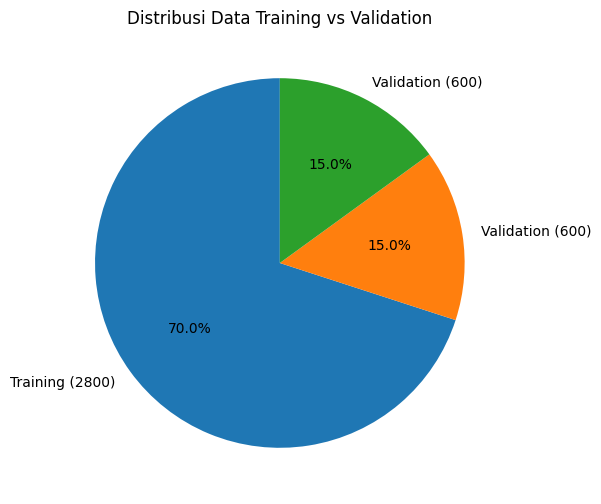

In [14]:
# Gunakan parameter augmentasi yang sudah kamu definisikan di train_datagen sebelumnya
# Gunakan rescale saja untuk val dan test

# 1. Train Generator (70%)
# Baris ini membuat data generator dari objek train_datagen
train_generator = train_datagen.flow_from_dataframe(
  dataframe=train_df, # Dataframe train_df digunakan sebagai sumber data
  x_col='filename', # Kolom dalam dataframe yang berisi nama atau lokasi file gambar
  y_col='label', # Kolom yang berisi label kelas dari setiap gambar.
  target_size=(IMG_WIDTH, IMG_HEIGHT), # Ukuran gambar yang akan digunakan model
  batch_size=BATCH_SIZE, # Menentukan ukuran batch
  class_mode='categorical', # Menentukan tipe klasifikasi
  shuffle=True, # Meningkatkan kemampuan generalisasi model
  seed=42 # Konsisten setiap kali eksperimen dijalankan
)

# 2. Validation Generator (15%)
validation_generator = validation_datagen.flow_from_dataframe(
  dataframe=val_df,
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  shuffle=True,
  seed=42
)

# 3. Test Generator (15%) - Gunakan validation_datagen karena hanya butuh rescale
test_generator = validation_datagen.flow_from_dataframe(
  dataframe=test_df,
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  # batch_size=BATCH_SIZE,
  batch_size=1,
  class_mode='categorical',
  shuffle=False, # Agar urutan hasil prediksi nanti mudah dicek
  seed=42
)

# 1. Ambil jumlah data dari generator
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Validation ({counts[2]})']

# 2. Plot diagram lingkaran (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

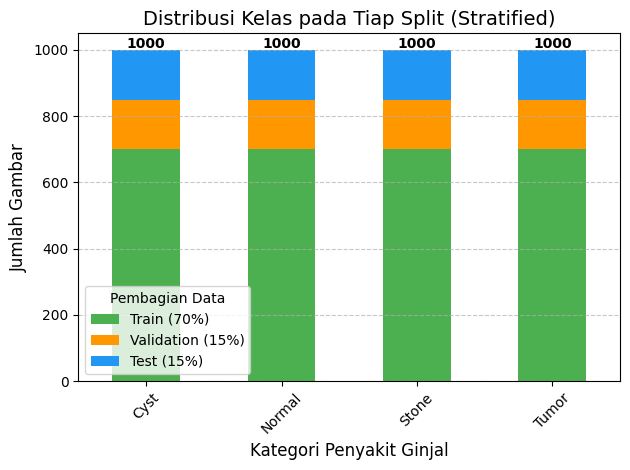

In [15]:
# Hitung jumlah data per kelas di masing-masing split
train_counts = train_df['label'].value_counts().sort_index()
val_counts = val_df['label'].value_counts().sort_index()
test_counts = test_df['label'].value_counts().sort_index()

# Siapkan Data untuk Plotting
categories = train_counts.index
df_plot = pd.DataFrame({ # Corrected 'Dataframe' to 'DataFrame'
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts
})

# Membuat Bar Chart
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Distribusi Kelas pada Tiap Split (Stratified)", fontsize=14)
plt.xlabel("Kategori Penyakit Ginjal", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)
plt.legend(title="Pembagian Data")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas setiap bar
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Kode dibawah mendefinisikan arsitektur jaringan saraf tiruan (Neural Network) menggunakan metode Transfer Learning. Model dibangun diatas fondasi yang sudah kuat (base_model) dan menambahkan "kepala" (top layers) baru untuk mengklasifikasi 4 jenis kondisi ginjal.

# VGG16

In [16]:
def build_VGG16_model():
  # Membuat model Xception yang sudah dilatih sebelumnya pada dataset ImageNet
  base_model = keras.applications.VGG16(
    # Model menggunakan layer klasifikasi terakhir (fully connected layer) ResNet.
    include_top=False,
    # Model menggunakan bobot yang sudah dilatih pada dataset ImageNet.
    weights='imagenet',
    # Menggunakan input tensor yang sudah dibuat sebelumnya.
    input_tensor=None,
    # Ukuran standar untuk banyak CNN.
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    # 4 Class pada data penyakit ginjal
    classes = 4,
    # Softmax digunakan untuk multi-class classification
    classifier_activation='softmax',
    # Nama model
    name='vgg16'
  )

  # Mengunci bobot pretrained agar tidak berubah saat training awal
  base_model.trainable = False

  # Menyusun arsitektur model
  model = models.Sequential([
    # Feature extractor dari DenseNet
    base_model,
    # Global average pooling operation untuk 2D data.
    layers.GlobalAveragePooling2D(),
    # Fully connected layer untuk pembelajaran pola penyakit
    layers.Dense(256, activation='relu'),
    # Menstabilkan distribusi aktivasi
    layers.BatchNormalization(),
    # Mengurangi overfitting
    layers.Dropout(0.3),
    # Output layer (4 kelas)
    layers.Dense(4, activation='softmax')  # Normal, Cyst, Tumor, Stone
  ])

  return model

# 2. Panggil fungsi untuk membuat model
VGG16_model = build_VGG16_model()

# 3. Tampilkan ringkasan arsitektur model
VGG16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,068 (56.64 MB)

 Trainable params: 132,868 (519.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

## Training Model

In [17]:
learning_rate = 0.0001
epochs = 25

# 4. Mulai Proses Pelatihan
VGG16_model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
  loss='categorical_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.AUC(
      name='auc',
      multi_label=True,
      num_labels=4
    )
  ]
)

history = VGG16_model.fit(
  train_generator,
  epochs=epochs, # Hyperparameter
  validation_data=validation_generator,
  verbose=1
)

Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 94s 883ms/step - accuracy: 0.3450 - auc: 0.6062 - loss: 1.6901 - val_accuracy: 0.5083 - val_auc: 0.8157 - val_loss: 1.2411
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 69s 788ms/step - accuracy: 0.4814 - auc: 0.7307 - loss: 1.3203 - val_accuracy: 0.6083 - val_auc: 0.8746 - val_loss: 0.9623
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 60s 687ms/step - accuracy: 0.5489 - auc: 0.7892 - loss: 1.1498 - val_accuracy: 0.6350 - val_auc: 0.8962 - val_loss: 0.8631
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 61s 695ms/step - accuracy: 0.5896 - auc: 0.8229 - loss: 1.0443 - val_accuracy: 0.7033 - val_auc: 0.9198 - val_loss: 0.7200
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 78s 655ms/step - accuracy: 0.6104 - auc: 0.8406 - loss: 0.9811 - val_accuracy: 0.7400 - val_auc: 0.9274 - val_loss: 0.6684
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 57s 652ms/step - accuracy: 0.6304 - auc: 0.8584 - loss: 0.9242 - val_accuracy: 0.7533 - val_auc: 0.9318 - val_loss: 0.6332
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━

## Visualisasi Training

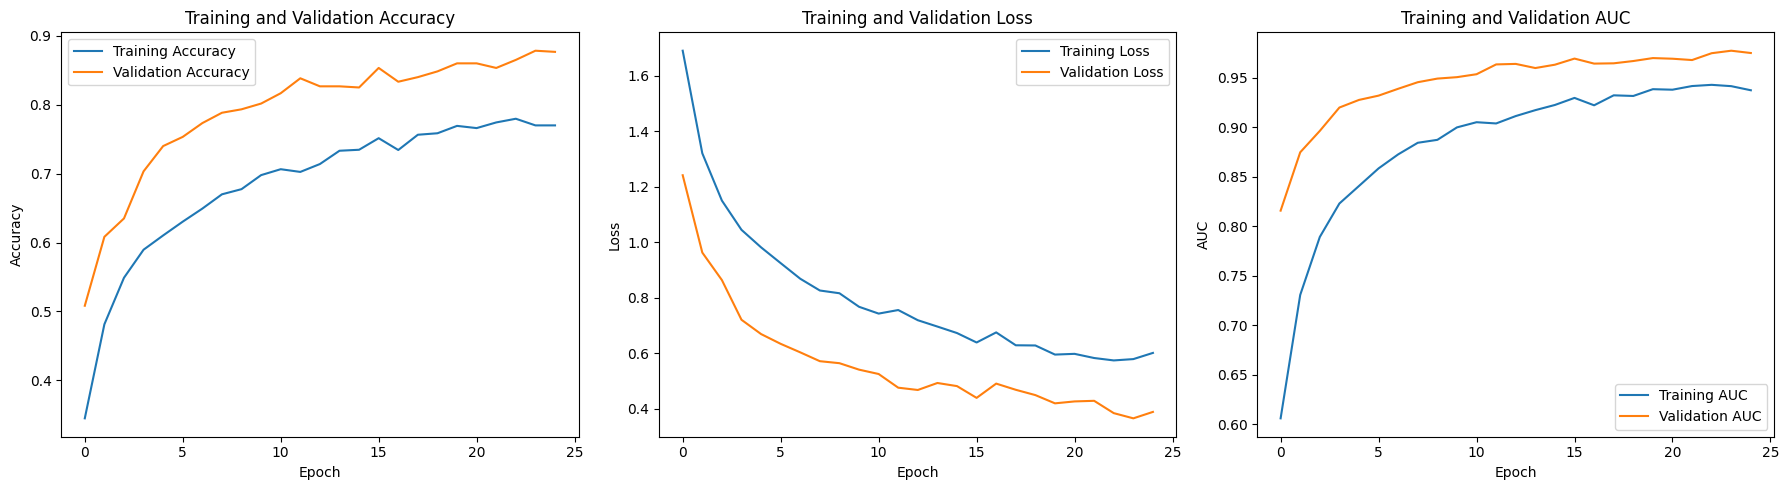

In [18]:
# Plot training and validation accuracy
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and Validation Loss
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluasi Model

In [19]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

# ==============
# Prediksi Model
# ==============

start_time = time.time()
Y_pred = VGG16_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder

# ==============
# Hitung Akurasi
# ==============

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Hyperparameter: ")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.4f}")
print(f"Total Waktu Prediksi : {inference_time:.2f} detik")

600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.0001
Epoch: 25
--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.8667
Total Waktu Prediksi : 9.53 detik


In [21]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

        Cyst      0.791     0.960     0.867       150
      Normal      0.899     0.887     0.893       150
       Stone      0.896     0.800     0.845       150
       Tumor      0.904     0.820     0.860       150

    accuracy                          0.867       600
   macro avg      0.872     0.867     0.866       600
weighted avg      0.872     0.867     0.866       600




--- Confusion Matrix ---


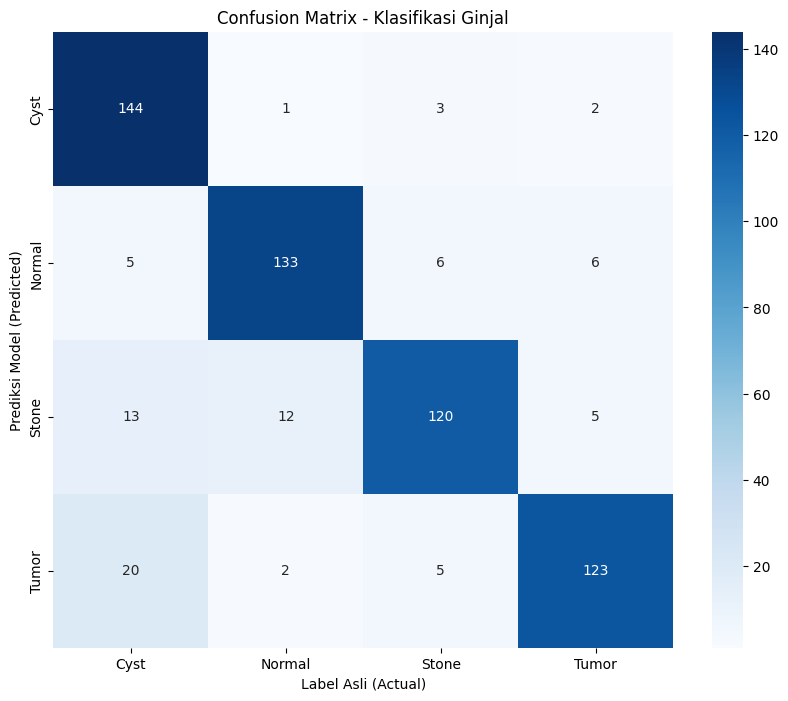

In [22]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

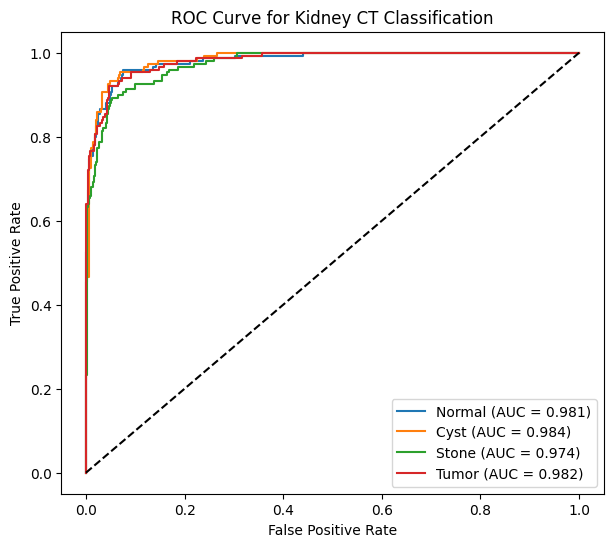

In [20]:
# ===================
# Persiapan ROC Curve
# ===================
# One-hot encoding label
y_true_onehot = to_categorical(y_true, num_classes=4)

# Dictionary untuk ROC
fpr = {}
tpr = {}
roc_auc = {}

# Hitung ROC untuk setiap kelas
for i in range(4):
  fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], Y_pred[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

# ==============================
# Visualisasi ROC Curve
# ==============================

class_names = ['Normal', 'Cyst', 'Stone', 'Tumor']

plt.figure(figsize=(7,6))

for i in range(4):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# Garis Random Classifier
plt.plot([0,1],[0,1],'k--')

plt.title('ROC Curve for Kidney CT Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()

# ResNet152

ResNet-152 dipilih karena memiliki jaringan yang sangat dalam dengan mekanisme residual connection yang mampu menangkap pola kompleks pada citra CT scan.

In [ ]:
def build_resnet_model():
  # Membuat model RestNet152 yang sudah dilatih sebelumnya pada dataset ImageNet
  base_model = keras.applications.ResNet152(
    # Model menggunakan layer klasifikasi terakhir (fully connected layer) ResNet.
    include_top=False,
    # Model menggunakan bobot yang sudah dilatih pada dataset ImageNet.
    weights='imagenet',
    # Menggunakan input tensor yang sudah dibuat sebelumnya.
    input_tensor=None,
    # Ukuran standar untuk banyak CNN.
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    # 4 Class pada data penyakit ginjal
    classes = 4,
    # Softmax digunakan untuk multi-class classification
    classifier_activation='softmax',
    # name="resnet152"
    name='resnet152'
  )
    # Mengunci pengetahuan asli base_model agar tidak rusak saat melatih lapisan baru.
  base_model.trainable = False

  # Menyusun Arsitektur Sequential
  model = models.Sequential([
    # Model ini sudah dilatih menggunakan jutaan gambar umum (ImageNet)
    base_model,
    # Mengurangi dimensi data secara drastis untuk mencegah overfitting
    layers.GlobalAveragePooling2D(),
    # Mempelajari hubungan logika antara tekstur gambar dengan jenis penyakit
    layers.Dense(256, activation='relu'),
    # Lapisan ini menstabilkan hasil perhitungan dari lapisan sebelumnya
    layers.BatchNormalization(),
    # Teknik pengamanan yang secara acak "mematikan" 30% saraf (neuron)
    layers.Dropout(0.3),
    # Lapisan terakhir yang menentukan hasil akhir diagnosa.
    layers.Dense(4, activation='softmax') # 4 Kelas: Normal, Cyst, Tumor, Stone
  ])

  return model

# 2. Panggil Fungsi untuk Membuat Model
RestNet_model = build_resnet_model()

# 3. Tampilkan Ringkasan Arsitektur (Model Summary)
# Ini akan menampilkan jumlah parameter dan urutan layer secara detail
RestNet_model.summary()

234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet152 (Functional)          │ (None, 7, 7, 2048)     │    58,370,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,897,540 (224.68 MB)

 Trainable params: 526,084 (2.01 MB)

 Non-trainable params: 58,371,456 (222.67 MB)

## Training Model

In [ ]:
learningRate = 0.0001
epochs = 25

# Mulai Proses Pelatihan
RestNet_model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=learningRate), #Hyperparameter
  loss='categorical_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.AUC(
      name='auc',
      multi_label=True,
      num_labels=4
    )
  ]
)

history = RestNet_model.fit(
  train_generator,
  epochs=epochs, # Hyperparameter
  validation_data=validation_generator,
  verbose=1
)

Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4436 - auc: 0.6964 - loss: 1.4042 - val_accuracy: 0.6567 - val_auc: 0.8770 - val_loss: 0.8692
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 60s 682ms/step - accuracy: 0.5768 - auc: 0.8209 - loss: 1.0345 - val_accuracy: 0.7067 - val_auc: 0.9058 - val_loss: 0.7636
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 61s 691ms/step - accuracy: 0.6225 - auc: 0.8537 - loss: 0.9328 - val_accuracy: 0.7533 - val_auc: 0.9422 - val_loss: 0.6508
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 61s 692ms/step - accuracy: 0.6721 - auc: 0.8851 - loss: 0.8225 - val_accuracy: 0.7517 - val_auc: 0.9476 - val_loss: 0.6276
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 60s 684ms/step - accuracy: 0.6886 - auc: 0.8974 - loss: 0.7739 - val_accuracy: 0.8100 - val_auc: 0.9590 - val_loss: 0.5112
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 60s 682ms/step - accuracy: 0.7086 - auc: 0.9058 - loss: 0.7399 - val_accuracy: 0.7950 - val_auc: 0.9542 - val_loss: 0.5333
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━━━

## Visualisasi Training

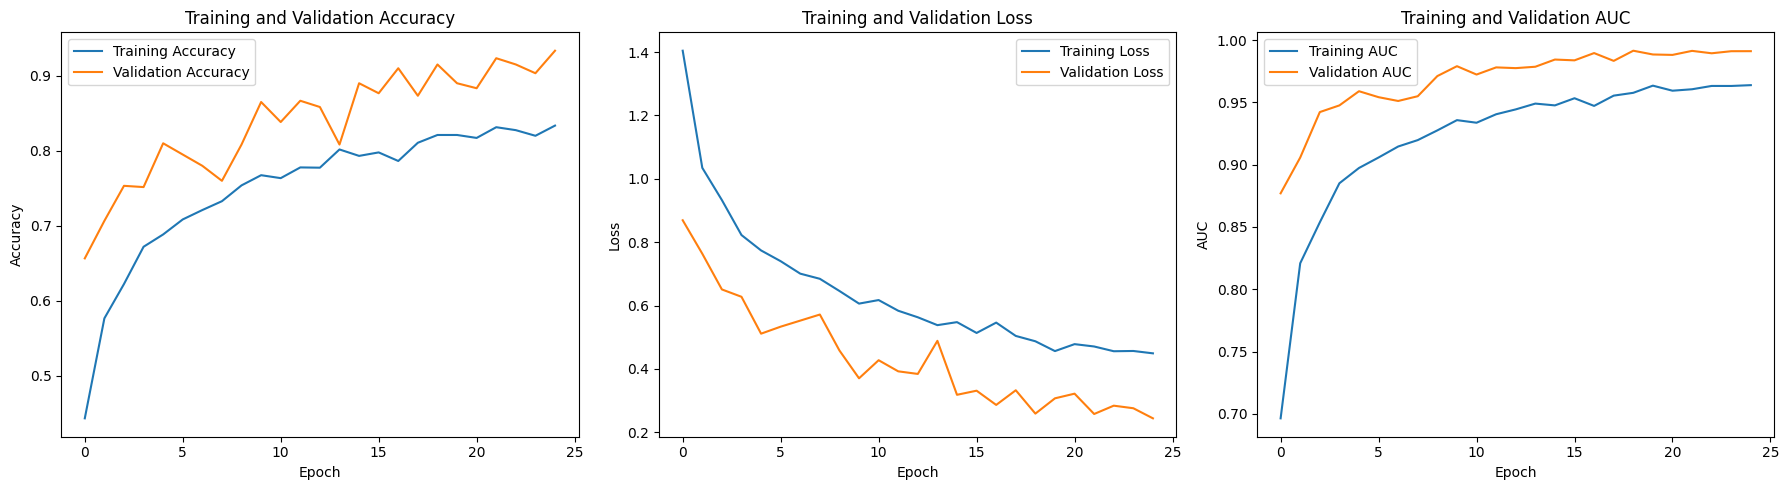

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and Validation Loss
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluasi Model

In [ ]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

# ==============
# Prediksi Model
# ==============

start_time = time.time()
Y_pred = RestNet_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder

# ==============
# Hitung Akurasi
# ==============

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Hyperparameter: ")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {learningRate}")
print(f"Epoch: {epochs}")

print(f"\n--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.4f}")
print(f"Total Waktu Prediksi : {inference_time:.2f} detik")

19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 836ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.0001
Epoch: 25

--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.9483
Total Waktu Prediksi : 28.20 detik


In [ ]:
# ===================
# Persiapan ROC Curve
# ===================
# One-hot encoding label
y_true_onehot = to_categorical(y_true, num_classes=4)

# Dictionary untuk ROC
fpr = {}
tpr = {}
roc_auc = {}

# Hitung ROC untuk setiap kelas
for i in range(4):
  fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], Y_pred[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

# ==============================
# Visualisasi ROC Curve
# ==============================

class_names = ['Normal', 'Cyst', 'Stone', 'Tumor']

plt.figure(figsize=(7,6))

for i in range(4):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# Garis Random Classifier
plt.plot([0,1],[0,1],'k--')

plt.title('ROC Curve for Kidney CT Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()

In [ ]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)

In [ ]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

# EfficientNetB0

EfficientNet-B0 dipilih karena memiliki arsitektur yang efisien dengan jumlah parameter yang relatif lebih sedikit namun tetap mampu memberikan performa klasifikasi yang tinggi.

In [26]:
# 1. Definisikan Fungsi Pembuat Model
def build_efficientnet_model():
  # Memuat Base Model (EfficientNetB0)
  base_model = EfficientNetB0(
    # Mengganti dengan lapisan baru yang khusus menebak 4 kondisi ginjal.
    include_top = False,
    # Menggunakan bobot (kecerdasan) yang sudah dipelajari dari (1,2 juta gambar)
    weights = 'imagenet',
    input_tensor = None,
    # Menentukan ukuran gambar masuk (224x224 piksel dengan 3 saluran warna (RGB).
    input_shape = (IMG_HEIGHT, IMG_WIDTH, 3),
    pooling = None,
    classifier_activation = "softmax",
    name = "efficientnetb0"
  )

  # Mengunci pengetahuan asli base_model agar tidak rusak saat melatih lapisan baru.
  base_model.trainable = False

  # Menyusun Arsitektur Sequential
  model = models.Sequential([
    # Model ini sudah dilatih menggunakan jutaan gambar umum (ImageNet)
    base_model,
    # Mengurangi dimensi data secara drastis untuk mencegah overfitting
    layers.GlobalAveragePooling2D(),
    # Mempelajari hubungan logika antara tekstur gambar dengan jenis penyakit
    layers.Dense(256, activation='relu'),
    # Lapisan ini menstabilkan hasil perhitungan dari lapisan sebelumnya
    layers.BatchNormalization(),
    # Teknik pengamanan yang secara acak "mematikan" 30% saraf (neuron)
    layers.Dropout(0.3),
    # Lapisan terakhir yang menentukan hasil akhir diagnosa.
    layers.Dense(4, activation='softmax') # 4 Kelas: Normal, Cyst, Tumor, Stone
  ])

  return model

# 2. Panggil Fungsi untuk Membuat Model
efficientNet_model = build_efficientnet_model()

# 3. Tampilkan Ringkasan Arsitektur (Model Summary)
# Ini akan menampilkan jumlah parameter dan urutan layer secara detail
efficientNet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## Training Model

In [27]:
# 4. Mulai Proses Pelatihan
learning_rate=0.0001
epochs=25

efficientNet_model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
  loss='categorical_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.AUC(
      name='auc',
      multi_label=True,
      num_labels=4
    )
  ]
)

history = efficientNet_model.fit(
  train_generator,
  epochs=epochs, # Hyperparameter
  validation_data=validation_generator,
  verbose=1
)

Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.4182 - auc: 0.6760 - loss: 1.4925 - val_accuracy: 0.6000 - val_auc: 0.8784 - val_loss: 1.0677
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 623ms/step - accuracy: 0.5839 - auc: 0.8180 - loss: 1.0603 - val_accuracy: 0.7450 - val_auc: 0.9218 - val_loss: 0.8291
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 61s 698ms/step - accuracy: 0.6354 - auc: 0.8603 - loss: 0.9184 - val_accuracy: 0.7917 - val_auc: 0.9521 - val_loss: 0.6615
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 591ms/step - accuracy: 0.6786 - auc: 0.8888 - loss: 0.8150 - val_accuracy: 0.8067 - val_auc: 0.9593 - val_loss: 0.5595
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 659ms/step - accuracy: 0.7150 - auc: 0.9073 - loss: 0.7372 - val_accuracy: 0.8550 - val_auc: 0.9678 - val_loss: 0.4613
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 597ms/step - accuracy: 0.7268 - auc: 0.9133 - loss: 0.7135 - val_accuracy: 0.8750 - val_auc: 0.9728 - val_loss: 0.4131
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━━━

## Visualisasi Training

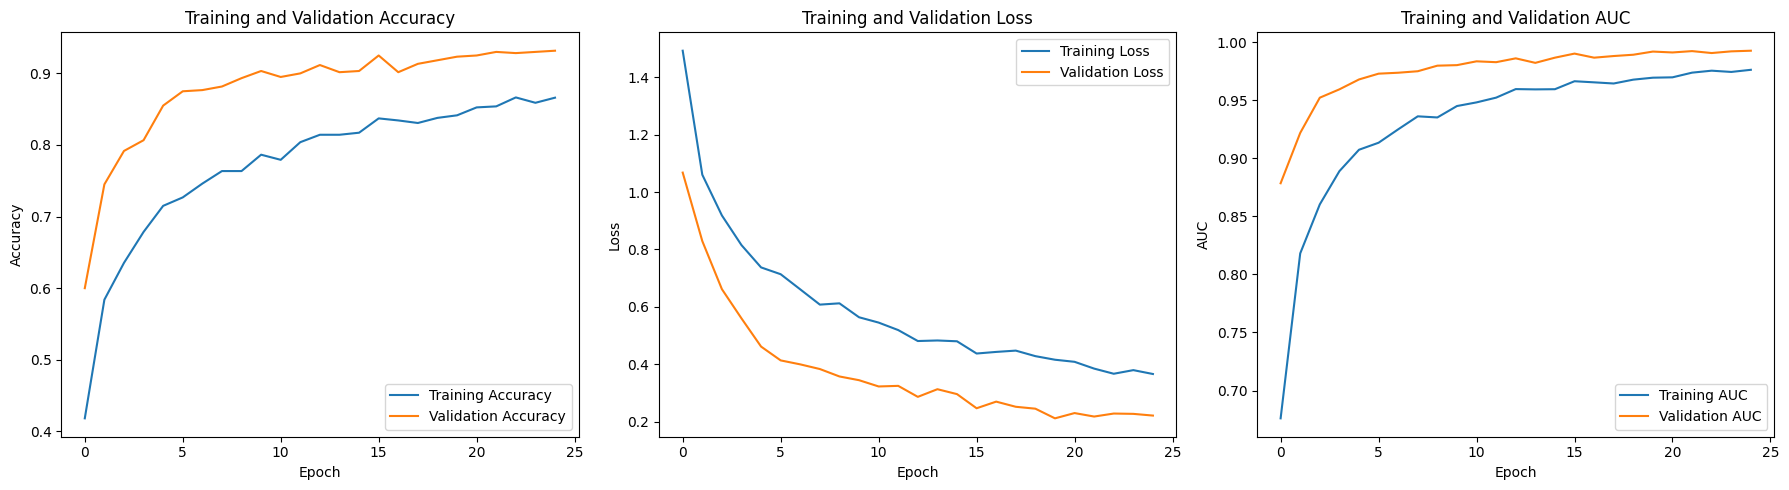

In [28]:
# Plot training and validation accuracy
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and Validation Loss
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluasi Model

In [29]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

# ==============
# Prediksi Model
# ==============

start_time = time.time()
Y_pred = efficientNet_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder

# ==============
# Hitung Akurasi
# ==============

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Hyperparameter: ")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.4f}")
print(f"Total Waktu Prediksi : {inference_time:.2f} detik")

600/600 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.0001
Epoch: 25
--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.9383
Total Waktu Prediksi : 18.76 detik


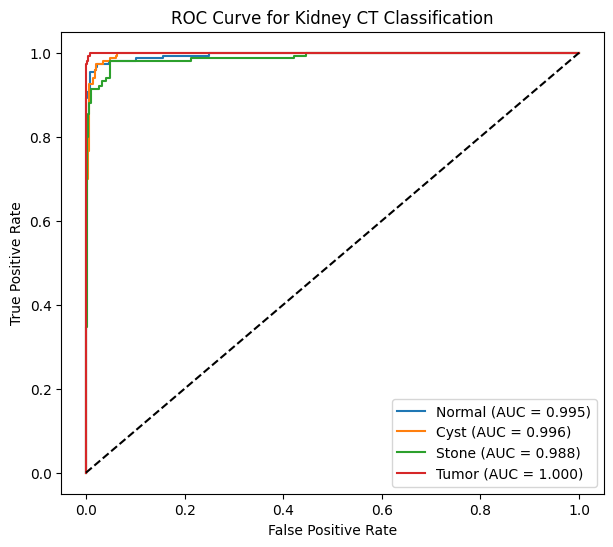

In [30]:
# ===================
# Persiapan ROC Curve
# ===================
# One-hot encoding label
y_true_onehot = to_categorical(y_true, num_classes=4)

# Dictionary untuk ROC
fpr = {}
tpr = {}
roc_auc = {}

# Hitung ROC untuk setiap kelas
for i in range(4):
  fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], Y_pred[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

# ==============================
# Visualisasi ROC Curve
# ==============================

class_names = ['Normal', 'Cyst', 'Stone', 'Tumor']

plt.figure(figsize=(7,6))

for i in range(4):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# Garis Random Classifier
plt.plot([0,1],[0,1],'k--')

plt.title('ROC Curve for Kidney CT Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()

In [31]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

        Cyst      0.972     0.920     0.945       150
      Normal      0.856     0.993     0.920       150
       Stone      0.943     0.887     0.914       150
       Tumor      1.000     0.953     0.976       150

    accuracy                          0.938       600
   macro avg      0.943     0.938     0.939       600
weighted avg      0.943     0.938     0.939       600




--- Confusion Matrix ---


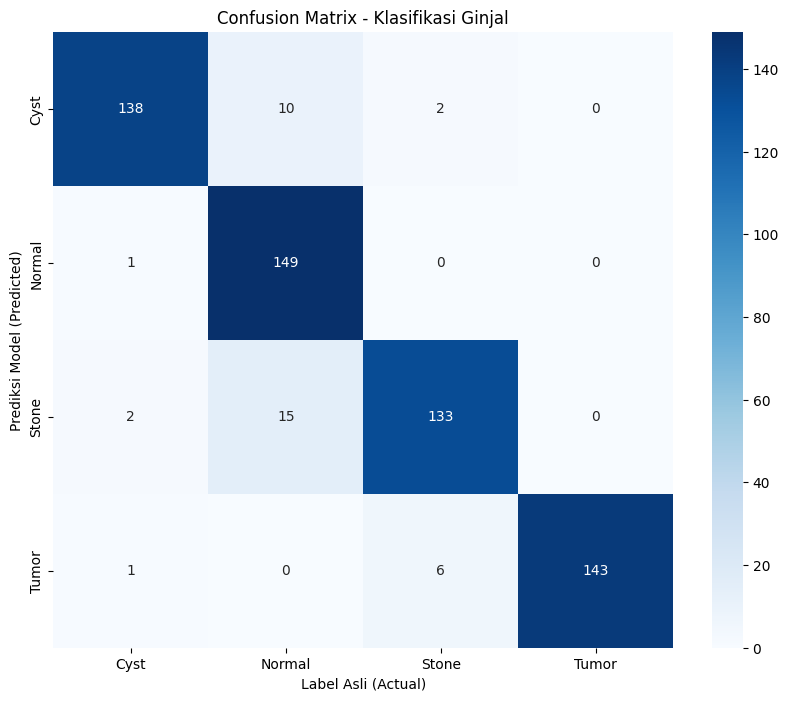

In [32]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

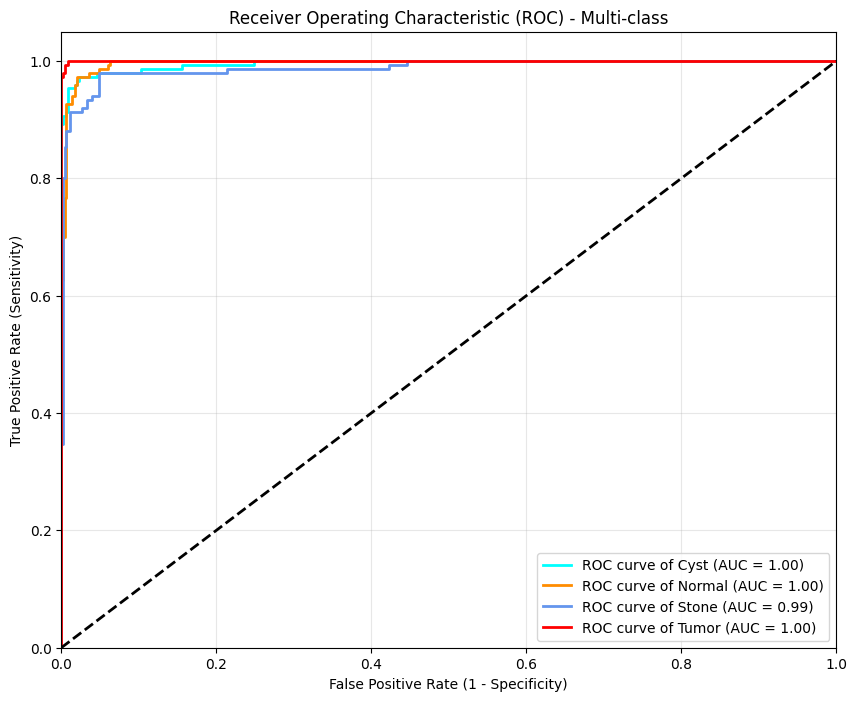

In [33]:
# 1. Persiapan Data
# Pastikan Y_pred adalah output probabilitas dari model.predict(test_generator)
# y_true adalah label asli dari test_generator.classes
n_classes = len(class_labels)

# Binarize label asli (misal: 2 menjadi [0, 0, 1, 0])
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# 2. Hitung ROC dan AUC untuk setiap kelas
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plot Kurva ROC
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_labels[i]} (AUC = {roc_auc[i]:.2f})')

# Plot garis bantu diagonal (random guess)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# New Image Prediction

Saving Cyst- (3709).jpg to Cyst- (3709).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


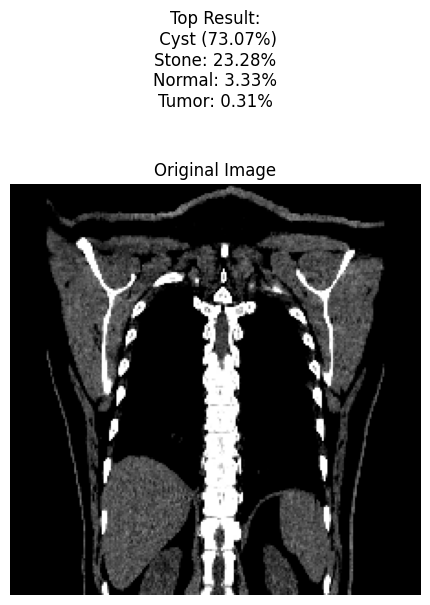

In [34]:
def predict_with_upload(model, class_indices):
  # 1. Trigger fitur upload file
  uploaded = files.upload()

  for file_name in uploaded.keys():
    # 2. Load gambar asli untuk tampilan visual
    img = image.load_img(file_name, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)

    # 3. PROSES SEGMENTASI (Wajib sama dengan saat training)
    img_segmented = combined_segmentation_preprocess(img_array)

    # Tambahkan dimensi batch (1, 224, 224, 3)
    img_ready = np.expand_dims(img_segmented, axis=0)

    # 4. Prediksi
    predictions = model.predict(img_ready)[0]
    class_names = list(class_indices.keys())

    # 5. Mengolah Hasil
    results = []
    for i in range(len(class_names)):
        results.append((class_names[i], predictions[i] * 100))

    # Sort dari persentase tertinggi
    results.sort(key=lambda x: x[1], reverse=True)

    # 6. Visualisasi (Hanya Original Image)
    plt.figure(figsize=(6, 6))

    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Tampilkan Teks Prediksi
    display_text = f"Top Result:\n {results[0][0]} ({results[0][1]:.2f}%)\n"
    for name, prob in results[1:]:
      display_text += f"{name}: {prob:.2f}%\n"

    plt.suptitle(display_text, fontsize=12, y=1)
    plt.tight_layout()
    plt.show()

# Cara Menjalankan:
# Contoh Prediksi Class Cyst
predict_with_upload(efficientNet_model, train_generator.class_indices)

Saving Normal- (5077).jpg to Normal- (5077).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


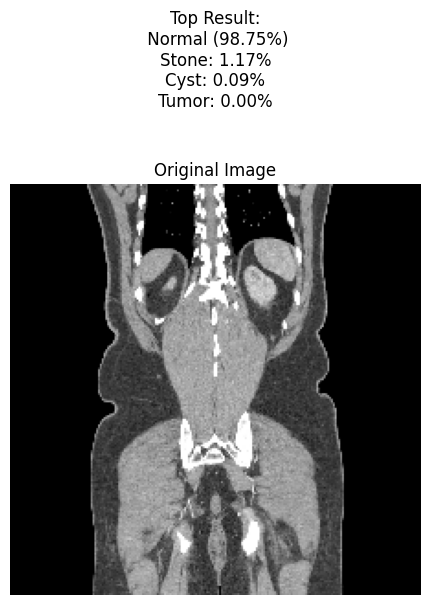

In [35]:
# Contoh Prediksi Class Normal
predict_with_upload(efficientNet_model, train_generator.class_indices)

Saving Stone- (1377).jpg to Stone- (1377).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


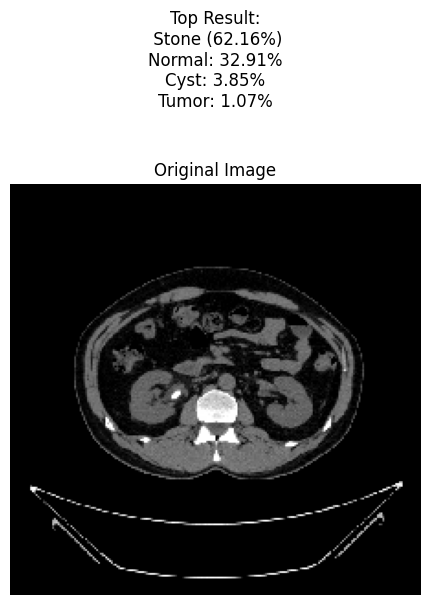

In [36]:
# Contoh Prediksi Class Stone
predict_with_upload(efficientNet_model, train_generator.class_indices)